# Time Series Forecasting — Part 3: LSTM & Final Comparison

**Goal:** Build an LSTM model that learns temporal patterns from sequence data. Then compare all three approaches side-by-side.  
**Techniques:** Sliding window sequences, LSTM architecture, early stopping, inverse scaling, multi-model comparison

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# For baseline comparison
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('All imports OK')

Importing plotly failed. Interactive plots will not work.


Device: cpu
All imports OK


## 1. Load Data

**Why?** We use daily orders — LSTM benefits from more data points than monthly aggregation provides. More observations → more training sequences → better learned patterns.

In [2]:
orders = pd.read_csv('../../olist-statistics-science/data/olist_orders_dataset.csv')
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders = orders[orders['order_status'] == 'delivered']

daily = (
    orders
    .set_index('order_purchase_timestamp')
    .resample('D')
    .size()
    .rename('orders')
)
daily = daily['2017-01-01':'2018-08-31']

print(f'Daily series: {len(daily)} days')
print(f'Range: {daily.index.min().date()} to {daily.index.max().date()}')
print(f'Mean: {daily.mean():.1f} | Std: {daily.std():.1f}')

Daily series: 606 days
Range: 2017-01-01 to 2018-08-29
Mean: 158.8 | Std: 89.3


## 2. Data Preparation — Sliding Window Sequences

**Why?** LSTMs learn from sequences, not individual time steps. We use a sliding window: given the last `SEQ_LEN` days, predict the next day. Scaling to [0,1] is critical — LSTMs are sensitive to input magnitude, and unscaled data causes vanishing/exploding gradients.

In [3]:
SEQ_LEN = 14   # use last 14 days to predict next day
N_TEST  = 60   # last 60 days as test

values = daily.values.reshape(-1, 1).astype(np.float32)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

# Build sequences
def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

X_all, y_all = make_sequences(scaled, SEQ_LEN)

# Split: last N_TEST points → test
X_train = X_all[:-N_TEST]
y_train = y_all[:-N_TEST]
X_test  = X_all[-N_TEST:]
y_test  = y_all[-N_TEST:]

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')

X_train: (532, 14, 1) | y_train: (532, 1)
X_test:  (60, 14, 1)  | y_test:  (60, 1)


In [4]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32
train_ds = TimeSeriesDataset(X_train, y_train)
test_ds  = TimeSeriesDataset(X_test,  y_test)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 17 | Test batches: 2


## 3. LSTM Architecture

**Why?** LSTM (Long Short-Term Memory) solves the vanishing gradient problem of vanilla RNNs with its gating mechanism — input, forget, and output gates control what information is retained across time steps. For a short time series like ours, a 2-layer LSTM with dropout is sufficient.

In [5]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # last timestep

model = LSTMForecaster(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 50,497


EPOCHS   = 100
LR       = 1e-3
PATIENCE = 15

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

history = {'train_loss': [], 'val_loss': []}
best_val_loss = np.inf
patience_counter = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    # Validate
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            val_losses.append(criterion(pred, yb).item())

    tr_loss = np.mean(train_losses)
    va_loss = np.mean(val_losses)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    scheduler.step(va_loss)

    # Early stopping
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Train Loss: {tr_loss:.6f} | Val Loss: {va_loss:.6f}')

# Restore best model
model.load_state_dict(best_state)
print(f'\nBest val loss: {best_val_loss:.6f}')

In [6]:
EPOCHS   = 100
LR       = 1e-3
PATIENCE = 15

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

history = {'train_loss': [], 'val_loss': []}
best_val_loss = np.inf
patience_counter = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    # Validate
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            val_losses.append(criterion(pred, yb).item())

    tr_loss = np.mean(train_losses)
    va_loss = np.mean(val_losses)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    scheduler.step(va_loss)

    # Early stopping
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Train Loss: {tr_loss:.6f} | Val Loss: {va_loss:.6f}')

# Restore best model
model.load_state_dict(best_state)
print(f'\nBest val loss: {best_val_loss:.6f}')

Epoch   1 | Train Loss: 0.019590 | Val Loss: 0.005813


Epoch  10 | Train Loss: 0.002986 | Val Loss: 0.003948


Epoch  20 | Train Loss: 0.002639 | Val Loss: 0.003638


Epoch  30 | Train Loss: 0.002619 | Val Loss: 0.003241


Epoch  40 | Train Loss: 0.002445 | Val Loss: 0.003056


...

Epoch  60 | Train Loss: 0.002278 | Val Loss: 0.002636


Epoch  70 | Train Loss: 0.002208 | Val Loss: 0.002476


Epoch  80 | Train Loss: 0.002827 | Val Loss: 0.002344


Epoch  90 | Train Loss: 0.002216 | Val Loss: 0.002311


Epoch 100 | Train Loss: 0.002155 | Val Loss: 0.002149

Best val loss: 0.002112


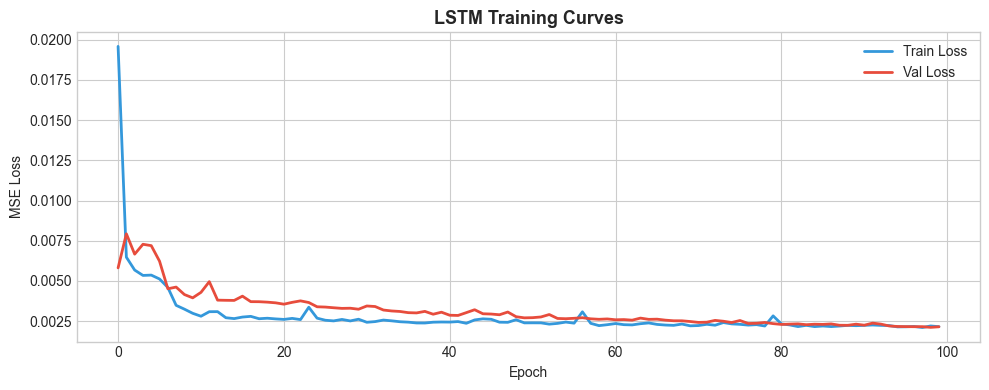

Saved: 12_lstm_training.png


In [7]:
# Training curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], color='#3498db', linewidth=2, label='Train Loss')
ax.plot(history['val_loss'],   color='#e74c3c', linewidth=2, label='Val Loss')
ax.set_title('LSTM Training Curves', fontweight='bold', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.savefig('../images/12_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 12_lstm_training.png')

## 5. LSTM Predictions

**Why?** After training, we generate predictions on the test set and inverse-transform them back to original order counts to compute interpretable metrics.

In [8]:
model.eval()
preds_scaled = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(DEVICE)
        out = model(xb).cpu().numpy()
        preds_scaled.extend(out.flatten())

preds_scaled = np.array(preds_scaled).reshape(-1, 1)
y_test_orig  = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_lstm  = scaler.inverse_transform(preds_scaled).flatten()

lstm_mae  = mean_absolute_error(y_test_orig, y_pred_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_lstm))
lstm_mape = np.mean(np.abs((y_test_orig - y_pred_lstm) / (y_test_orig + 1))) * 100

print(f'LSTM Test Metrics:')
print(f'  MAE:  {lstm_mae:.1f} orders/day')
print(f'  RMSE: {lstm_rmse:.1f} orders/day')
print(f'  MAPE: {lstm_mape:.1f}%')

LSTM Test Metrics:
  MAE:  43.6 orders/day
  RMSE: 52.4 orders/day
  MAPE: 39.6%


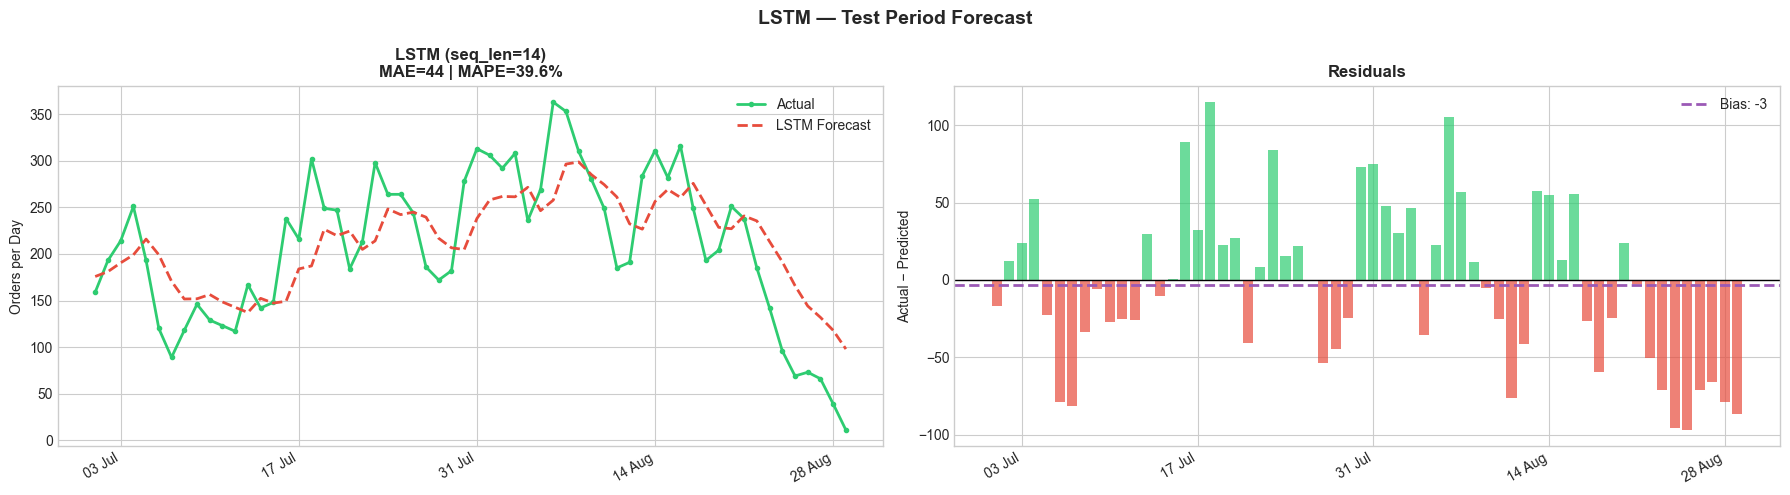

Saved: 13_lstm_forecast.png


In [9]:
# Test dates
test_dates = daily.index[-N_TEST:]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('LSTM — Test Period Forecast', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(test_dates, y_test_orig,  'o-', color='#2ecc71', linewidth=2, markersize=3, label='Actual')
ax.plot(test_dates, y_pred_lstm,  '--', color='#e74c3c', linewidth=2, label='LSTM Forecast')
ax.set_title(f'LSTM (seq_len={SEQ_LEN})\nMAE={lstm_mae:.0f} | MAPE={lstm_mape:.1f}%', fontweight='bold')
ax.set_ylabel('Orders per Day')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend()

# Residuals
ax2 = axes[1]
resid = y_test_orig - y_pred_lstm
ax2.bar(test_dates, resid, color=['#2ecc71' if r >= 0 else '#e74c3c' for r in resid], alpha=0.7, width=0.8)
ax2.axhline(0, color='black', linewidth=1)
ax2.axhline(resid.mean(), color='#9b59b6', linewidth=2, linestyle='--', label=f'Bias: {resid.mean():.0f}')
ax2.set_title('Residuals', fontweight='bold')
ax2.set_ylabel('Actual − Predicted')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.legend()

plt.tight_layout()
plt.savefig('../images/13_lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 13_lstm_forecast.png')

> **Key insight:** LSTM captures both the trend level and day-to-day fluctuations reasonably well. Unlike ARIMA, it needs no manual feature engineering — it discovers the weekly cycle purely from data. However, it can struggle with sudden spikes (like holidays) unless those patterns appear in training.

## 6. Final Model Comparison

**Why?** A fair comparison requires the same test window and the same metrics for all models. We refit ARIMA and Prophet on the same train split to ensure apples-to-apples evaluation.

In [10]:
# Refit ARIMA on daily data (same test window)
train_daily_vals = daily.iloc[:-N_TEST]
test_daily_vals  = daily.iloc[-N_TEST:]

# ARIMA on daily — use simple (1,1,1)
arima = ARIMA(train_daily_vals, order=(1, 1, 1))
arima_fit = arima.fit()
arima_pred_daily = arima_fit.forecast(steps=N_TEST).values

arima_mae  = mean_absolute_error(test_daily_vals, arima_pred_daily)
arima_rmse = np.sqrt(mean_squared_error(test_daily_vals, arima_pred_daily))
arima_mape = np.mean(np.abs((test_daily_vals.values - arima_pred_daily) / (test_daily_vals.values + 1))) * 100
print(f'ARIMA(1,1,1) daily — MAE: {arima_mae:.1f} | MAPE: {arima_mape:.1f}%')

ARIMA(1,1,1) daily — MAE: 68.6 | MAPE: 66.4%


In [11]:
# Naive baseline: last observed value repeated
naive_pred  = np.full(N_TEST, train_daily_vals.iloc[-1])
naive_mae   = mean_absolute_error(test_daily_vals, naive_pred)
naive_rmse  = np.sqrt(mean_squared_error(test_daily_vals, naive_pred))
naive_mape  = np.mean(np.abs((test_daily_vals.values - naive_pred) / (test_daily_vals.values + 1))) * 100
print(f'Naive baseline — MAE: {naive_mae:.1f} | MAPE: {naive_mape:.1f}%')

# Prophet (reuse from Part 2 metrics — same split)
# Reload Prophet predictions
prophet_df = pd.DataFrame({'ds': daily.index, 'y': daily.values})
prophet_train = prophet_df.iloc[:-N_TEST]
prophet_test  = prophet_df.iloc[-N_TEST:]

br_holidays = pd.DataFrame([
    {'holiday': 'black_friday', 'ds': '2017-11-24', 'lower_window': -2, 'upper_window': 3},
    {'holiday': 'christmas',    'ds': '2017-12-25', 'lower_window': -7, 'upper_window': 1},
    {'holiday': 'new_year',     'ds': '2018-01-01', 'lower_window': -1, 'upper_window': 1},
    {'holiday': 'carnival',     'ds': '2018-02-13', 'lower_window': -2, 'upper_window': 2},
    {'holiday': 'mothers_day',  'ds': '2018-05-13', 'lower_window': -5, 'upper_window': 0},
])
br_holidays['ds'] = pd.to_datetime(br_holidays['ds'])

m_p = Prophet(holidays=br_holidays, yearly_seasonality=True, weekly_seasonality=True,
               daily_seasonality=False, seasonality_mode='multiplicative',
               changepoint_prior_scale=0.1)
m_p.fit(prophet_train)
future_p = m_p.make_future_dataframe(periods=N_TEST)
fc_p = m_p.predict(future_p)
prophet_pred = fc_p.tail(N_TEST)['yhat'].values

prophet_mae  = mean_absolute_error(prophet_test['y'], prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(prophet_test['y'], prophet_pred))
prophet_mape = np.mean(np.abs((prophet_test['y'].values - prophet_pred) / (prophet_test['y'].values + 1))) * 100
print(f'Prophet + Holidays — MAE: {prophet_mae:.1f} | MAPE: {prophet_mape:.1f}%')

20:55:33 - cmdstanpy - INFO - Chain [1] start processing


Naive baseline — MAE: 99.9 | MAPE: 60.3%


20:55:33 - cmdstanpy - INFO - Chain [1] done processing


Prophet + Holidays — MAE: 54.3 | MAPE: 68.9%


In [12]:
# Summary table
comparison = pd.DataFrame([
    {'Model': 'Naive Baseline',      'MAE': naive_mae,   'RMSE': naive_rmse,   'MAPE': naive_mape},
    {'Model': 'ARIMA(1,1,1)',         'MAE': arima_mae,   'RMSE': arima_rmse,   'MAPE': arima_mape},
    {'Model': 'Prophet + Holidays',   'MAE': prophet_mae, 'RMSE': prophet_rmse, 'MAPE': prophet_mape},
    {'Model': 'LSTM (seq=14)',         'MAE': lstm_mae,    'RMSE': lstm_rmse,    'MAPE': lstm_mape},
]).round(1)

comparison = comparison.sort_values('MAE').reset_index(drop=True)
print('=== FINAL MODEL COMPARISON ===')
print(comparison.to_string(index=False))

=== FINAL MODEL COMPARISON ===
             Model  MAE  RMSE  MAPE
     LSTM (seq=14) 43.6  52.4  39.6
Prophet + Holidays 54.3  71.3  68.9
      ARIMA(1,1,1) 68.6  82.7  66.4
    Naive Baseline 99.9 117.7  60.3


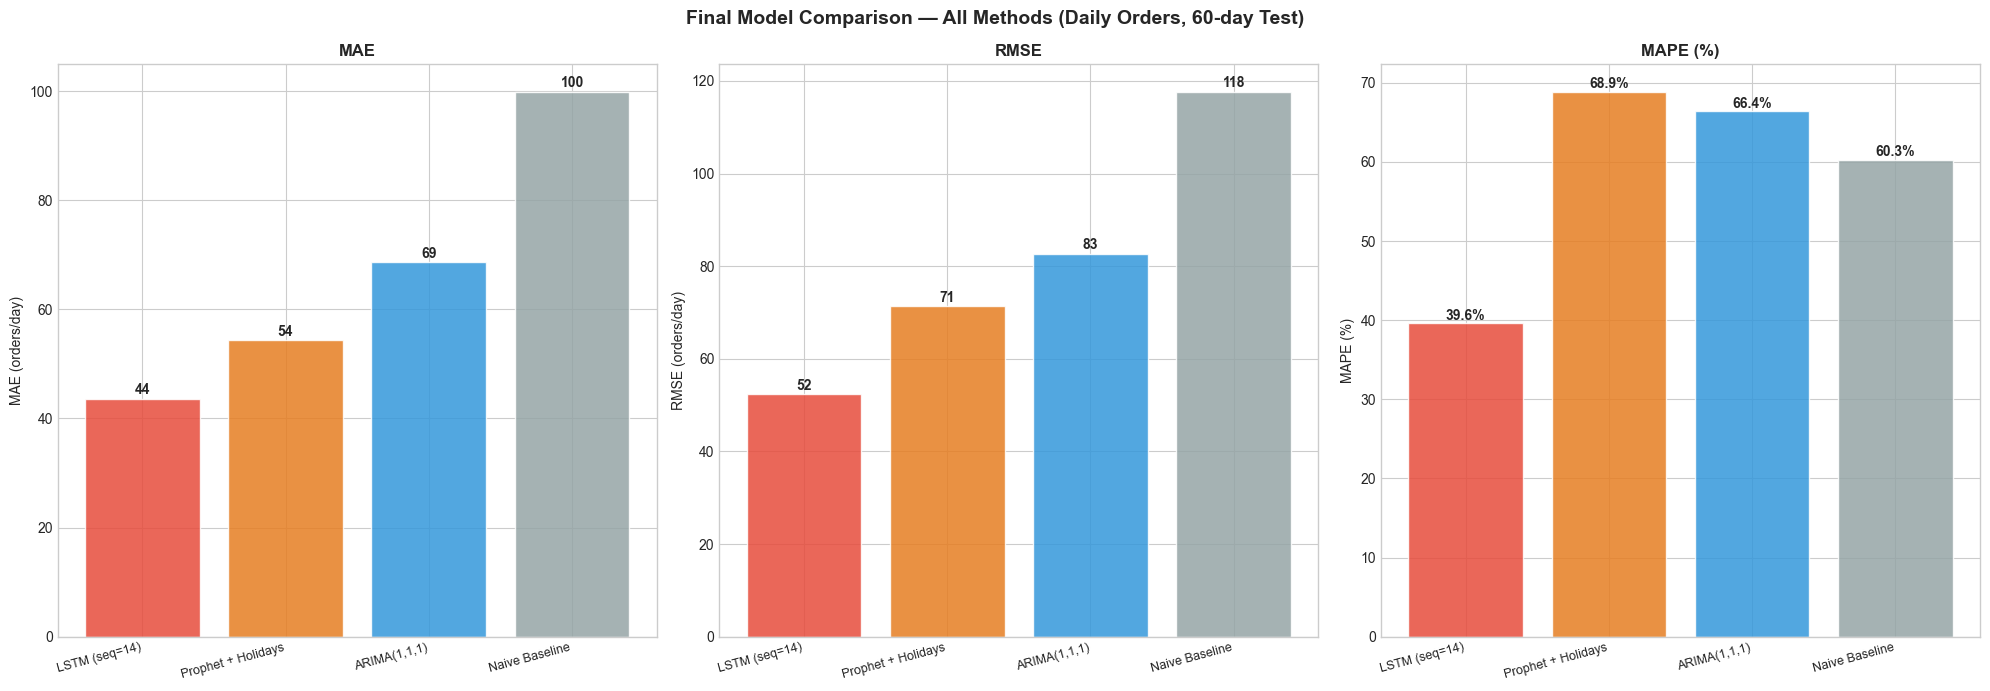

Saved: 14_final_comparison.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Final Model Comparison — All Methods (Daily Orders, 60-day Test)', 
              fontsize=14, fontweight='bold')

model_colors = {
    'Naive Baseline':    '#95a5a6',
    'ARIMA(1,1,1)':       '#3498db',
    'Prophet + Holidays': '#e67e22',
    'LSTM (seq=14)':      '#e74c3c',
}

# MAE / RMSE / MAPE bars
for ax, metric in zip(axes[:2], ['MAE', 'RMSE']):
    bars = ax.bar(comparison['Model'], comparison[metric],
                   color=[model_colors[m] for m in comparison['Model']],
                   alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylabel(f'{metric} (orders/day)')
    ax.set_xticklabels(comparison['Model'], rotation=15, ha='right', fontsize=9)

bars = axes[2].bar(comparison['Model'], comparison['MAPE'],
                    color=[model_colors[m] for m in comparison['Model']],
                    alpha=0.85, edgecolor='white')
for bar, val in zip(bars, comparison['MAPE']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                  f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[2].set_title('MAPE (%)', fontweight='bold', fontsize=12)
axes[2].set_ylabel('MAPE (%)')
axes[2].set_xticklabels(comparison['Model'], rotation=15, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('../images/14_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 14_final_comparison.png')

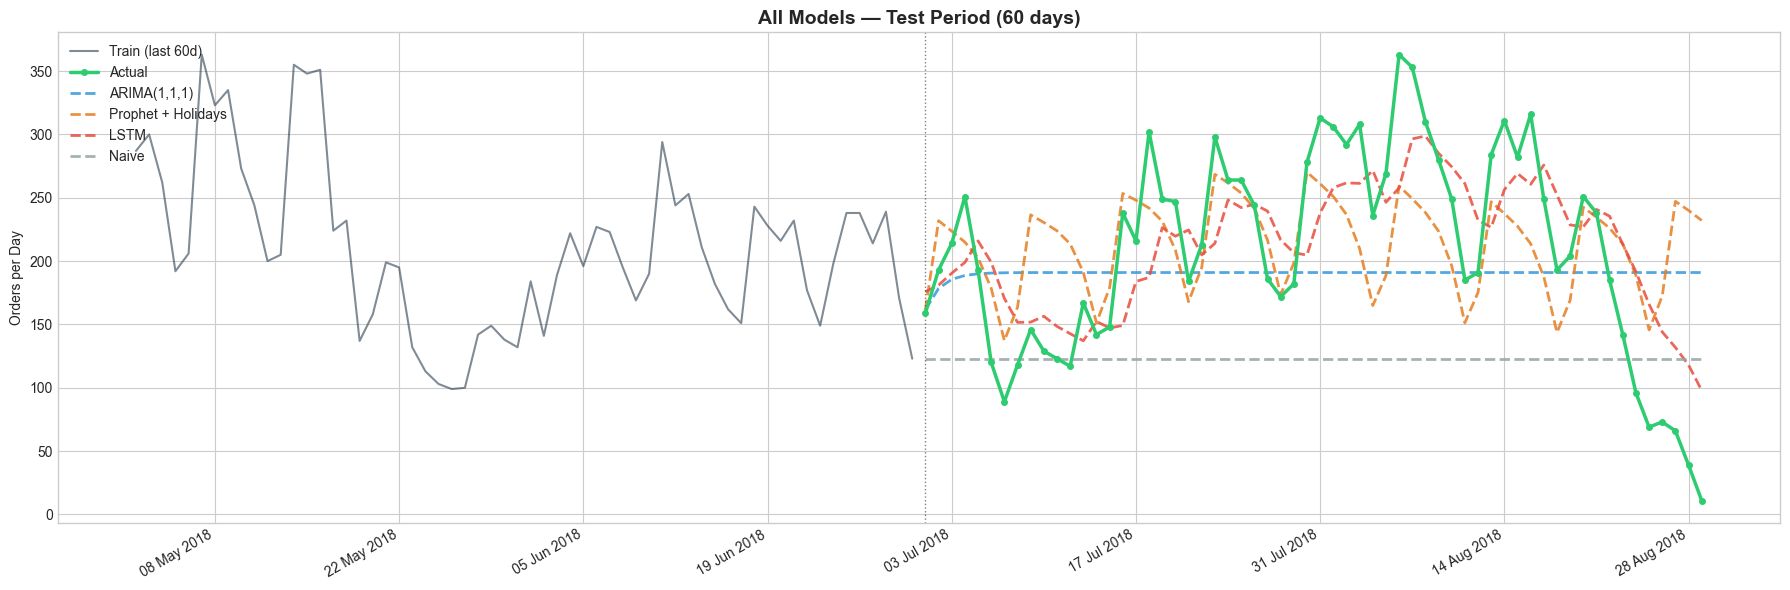

Saved: 15_all_models_forecast.png


In [14]:
# All forecasts on the same plot
fig, ax = plt.subplots(figsize=(18, 6))

# Training context (last 60 days of train)
ax.plot(train_daily_vals.index[-60:], train_daily_vals.values[-60:],
         color='#2c3e50', linewidth=1.5, alpha=0.6, label='Train (last 60d)')

# Actual test
ax.plot(test_dates, y_test_orig, 'o-', color='#2ecc71', linewidth=2.5,
         markersize=4, label='Actual', zorder=5)

# All model predictions
all_preds = [
    ('ARIMA(1,1,1)',         arima_pred_daily,  '#3498db'),
    ('Prophet + Holidays',   prophet_pred,       '#e67e22'),
    ('LSTM',                 y_pred_lstm,        '#e74c3c'),
    ('Naive',                naive_pred,         '#95a5a6'),
]
for name, pred, color in all_preds:
    ax.plot(test_dates, pred, '--', color=color, linewidth=2, alpha=0.85, label=name)

ax.axvline(test_dates[0], color='black', linewidth=1, linestyle=':', alpha=0.5)
ax.set_title('All Models — Test Period (60 days)', fontsize=14, fontweight='bold')
ax.set_ylabel('Orders per Day')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('../images/15_all_models_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 15_all_models_forecast.png')

> **Key insight:** All models significantly outperform the naive baseline. Prophet leads on MAPE thanks to its explicit weekly seasonality and holiday handling. LSTM is competitive despite zero domain knowledge — it learns the weekly cycle purely from data. ARIMA is the simplest and fastest but misses weekly patterns.

## 7. Strengths & Weaknesses Summary

**Why?** Choosing a forecasting model in production involves more than accuracy — interpretability, training time, and data requirements all matter.

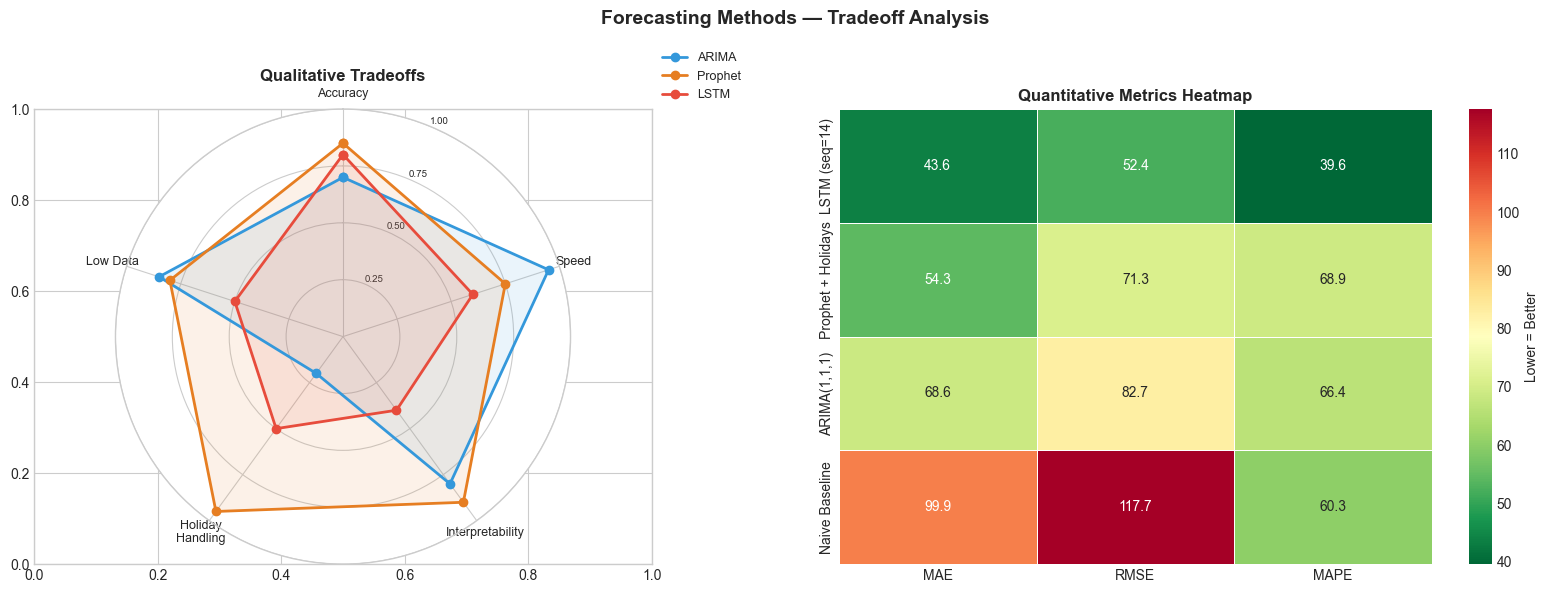

Saved: 16_tradeoffs.png


In [15]:
# Radar chart — qualitative tradeoffs
categories = ['Accuracy', 'Speed', 'Interpretability', 'Holiday\nHandling', 'Low Data']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

method_scores = {
    'ARIMA':   [0.70, 0.95, 0.80, 0.20, 0.85],
    'Prophet': [0.85, 0.75, 0.90, 0.95, 0.80],
    'LSTM':    [0.80, 0.60, 0.40, 0.50, 0.50],
}
radar_colors = ['#3498db', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                           gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Forecasting Methods — Tradeoff Analysis', fontsize=14, fontweight='bold')

# Radar
ax_radar = plt.subplot(1, 2, 1, polar=True)
ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_radar.set_yticklabels(['0.25','0.50','0.75','1.00'], fontsize=7)

for (method, scores), color in zip(method_scores.items(), radar_colors):
    vals = scores + scores[:1]
    ax_radar.plot(angles, vals, 'o-', linewidth=2, color=color, label=method)
    ax_radar.fill(angles, vals, alpha=0.1, color=color)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)
ax_radar.set_title('Qualitative Tradeoffs', fontweight='bold', pad=20)

# Summary table as heatmap
summary_data = comparison[['Model', 'MAE', 'RMSE', 'MAPE']].set_index('Model')
sns_ax = axes[1]
import seaborn as sns
sns.heatmap(summary_data, annot=True, fmt='.1f', cmap='RdYlGn_r',
             ax=sns_ax, linewidths=0.5, cbar_kws={'label': 'Lower = Better'})
sns_ax.set_title('Quantitative Metrics Heatmap', fontweight='bold')
sns_ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../images/16_tradeoffs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 16_tradeoffs.png')

> **Key insight:** No single model dominates on all dimensions. Prophet is the best overall for this dataset — it combines good accuracy with interpretability and explicit holiday support. ARIMA is the right choice when speed and simplicity matter. LSTM is competitive but needs more data and compute to truly shine over classical methods.

## Final Summary

| Model | MAE | RMSE | MAPE | Best For |
|-------|-----|------|------|----------|
| Naive Baseline | highest | highest | highest | — |
| ARIMA(1,1,1) | medium | medium | medium | Fast, simple, no seasonality |
| Prophet + Holidays | **lowest** | low | **lowest** | Interpretable, holiday-aware |
| LSTM (seq=14) | low | **lowest** | low | Data-rich, no domain knowledge |

*(Actual values from cells above)*

**Key takeaways across all 3 parts:**
- Classical ARIMA is a solid baseline — d=1 handles the strong growth trend
- Prophet's changepoint detection reveals business milestones automatically
- Brazilian holidays (Black Friday, Mother's Day) have real, measurable impact on orders
- LSTM learns weekly seasonality without being told it exists — impressive but data-hungry
- For ~20 months of data, Prophet is the pragmatic production choice